<a href="https://colab.research.google.com/github/shaunyttan-cell/MDA5013_SHAUN_TAN_YAN_TAT_25119033_Assignment-2.2/blob/main/MDA5013_25119033_Shaun_Tan_Yan_Tat_Assessment_2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import os

print("Go to Kaggle → Settings → API Tokens → Generate New Token")
print("Copy the code block shown there and paste it below.")

username = input("KAGGLE_USERNAME: ")
key = input("KAGGLE_KEY: ")

# Create the kaggle.json file manually
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    f.write(f'{{"username":"{username}","key":"{key}"}}')

!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

Go to Kaggle → Settings → API Tokens → Generate New Token
Copy the code block shown there and paste it below.
KAGGLE_USERNAME: User
KAGGLE_KEY: KEY


In [2]:
!kaggle datasets download -d lakshmi25npathi/bike-sharing-dataset
!unzip -o -q bike-sharing-dataset.zip
!ls -la *.csv

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset
License(s): unknown
100% 286k/286k [00:00<00:00, 124MB/s]

-rw-r--r-- 1 root root   57569 Oct 19  2019 day.csv
-rw-r--r-- 1 root root 1156736 Oct 19  2019 hour.csv


In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                        ReduceLROnPlateau)

In [4]:
# Fix random seeds so results are reproducible across runs
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
# Global configuration
LOOKBACK   = 24     # hours of history per sample (natural daily cycle)
UNITS      = 64     # recurrent layer width
BATCH_SIZE = 128
EPOCHS     = 50     # EarlyStopping will usually halt before this
LR         = 1e-3   # standard Adam rate for small recurrent models

print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
# 1. DATA PREPROCESSING

# Load the hourly dataset (17,379 records, 2011-2012)
df = pd.read_csv("hour.csv")
print("Shape:", df.shape)
df.head()

Shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [7]:
# Feature selection.
# 'instant' is a row index and 'dteday' a date string: no predictive value.
# 'casual' and 'registered' sum exactly to the target 'cnt' and are excluded
# to prevent target leakage.
FEATURES = ["season", "yr", "mnth", "hr", "holiday", "weekday",
            "workingday", "weathersit", "temp", "atemp", "hum", "windspeed"]
TARGET   = "cnt"

data = df[FEATURES + [TARGET]].copy()
print("Features:", len(FEATURES), "| Target:", TARGET)
print("Any missing values:", data.isnull().values.any())

Features: 12 | Target: cnt
Any missing values: False


In [8]:
# Chronological split: 70% train / 10% validation / 20% test.
# Order is preserved - shuffling a time series would leak the future
# into the past and invalidate the evaluation.
n = len(data)
i_train = int(n * 0.70)
i_val   = int(n * 0.80)

train_raw = data.iloc[:i_train]
val_raw   = data.iloc[i_train:i_val]
test_raw  = data.iloc[i_val:]
print(f"Train: {len(train_raw)} | Val: {len(val_raw)} | Test: {len(test_raw)}")

Train: 12165 | Val: 1738 | Test: 3476


In [9]:
# Scaling: fit BOTH scalers on the training partition only, then apply to
# validation and test - prevents information leakage from unseen data.
# A separate target scaler lets predictions be inverse-transformed back to
# real rental counts for interpretable error metrics.
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train = x_scaler.fit_transform(train_raw[FEATURES])
X_val   = x_scaler.transform(val_raw[FEATURES])
X_test  = x_scaler.transform(test_raw[FEATURES])

y_train = y_scaler.fit_transform(train_raw[[TARGET]])
y_val   = y_scaler.transform(val_raw[[TARGET]])
y_test  = y_scaler.transform(test_raw[[TARGET]])

In [10]:
# Windowing: convert the series into supervised samples. Each sample is the
# previous `lookback` hours of features; the label is the rental count of the
# following hour. Windowing is done within each partition independently to
# prevent sequences straddling the train/val/test boundaries.
def make_windows(X, y, lookback):
    xs, ys = [], []
    for i in range(lookback, len(X)):
        xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(xs), np.array(ys)

Xtr, ytr = make_windows(X_train, y_train, LOOKBACK)
Xva, yva = make_windows(X_val,   y_val,   LOOKBACK)
Xte, yte = make_windows(X_test,  y_test,  LOOKBACK)

print("Train windows:", Xtr.shape, "| Val:", Xva.shape, "| Test:", Xte.shape)
# Shape: (samples, lookback, n_features) - the 3D input RNN layers require

Train windows: (12141, 24, 12) | Val: (1714, 24, 12) | Test: (3452, 24, 12)


In [11]:
# 2. MODEL BUILDING

# Factory for the three recurrent architectures of matched capacity.
# cell_type: 'SimpleRNN' | 'LSTM' | 'GRU'
# Dropout is a separate layer (not the recurrent layer's dropout argument)
# so the cuDNN GPU fast path stays active.
def build_model(cell_type, units=UNITS, lookback=LOOKBACK, n_features=len(FEATURES)):
    layer = {"SimpleRNN": SimpleRNN, "LSTM": LSTM, "GRU": GRU}[cell_type]
    model = Sequential([
        tf.keras.Input(shape=(lookback, n_features)),
        layer(units),                 # recurrent layer
        Dropout(0.2),                 # regularisation to curb overfitting
        Dense(1)                      # linear output for regression
    ], name=cell_type)
    model.compile(optimizer=Adam(learning_rate=LR), loss="mse", metrics=["mae"])
    return model

# Architecture summaries for Appendix A (Figures A1-A3)
for name in ["SimpleRNN", "LSTM", "GRU"]:
    print(f"\n--- {name} architecture ---")
    build_model(name).summary()


--- SimpleRNN architecture ---


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,993 (19.50 KB)

...

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        14,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,041 (58.75 KB)

 Trainable params: 15,041 (58.75 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# 3. MODEL TRAINING

# EarlyStopping restores best weights; ModelCheckpoint saves the best model;
# ReduceLROnPlateau halves the learning rate when validation loss plateaus.
def make_callbacks(tag, patience=6):
    return [
        EarlyStopping(monitor="val_loss", patience=patience,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(f"best_{tag}.keras", monitor="val_loss",
                        save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3,
                          min_lr=1e-6, verbose=1)
    ]

# Train one model and evaluate on the test partition. Metrics are returned in
# REAL rental-count units (inverse-transformed), plus training time and history.
def train_and_evaluate(cell_type, Xtr, ytr, Xva, yva, Xte, yte,
                       units=UNITS, lookback=LOOKBACK, tag_suffix=""):
    tag = f"{cell_type}{tag_suffix}"
    model = build_model(cell_type, units=units, lookback=lookback)

    start = time.time()
    history = model.fit(Xtr, ytr, validation_data=(Xva, yva),
                        epochs=EPOCHS, batch_size=BATCH_SIZE,
                        callbacks=make_callbacks(tag), verbose=0)
    train_time = time.time() - start

    pred = y_scaler.inverse_transform(model.predict(Xte, verbose=0)).ravel()
    true = y_scaler.inverse_transform(yte).ravel()

    mse  = mean_squared_error(true, pred)
    rmse = float(np.sqrt(mse))
    mae  = mean_absolute_error(true, pred)

    print(f"----- {tag} (units={units}, lookback={lookback}) -----")
    print(f"MSE : {mse:10.2f}")
    print(f"RMSE: {rmse:10.2f}   <-- primary metric (rental-count units)")
    print(f"MAE : {mae:10.2f}   <-- secondary metric")
    print(f"Training time: {train_time:.1f}s | Epochs run: {len(history.history['loss'])}\n")

    return {"name": cell_type, "tag": tag, "units": units, "lookback": lookback,
            "mse": mse, "rmse": rmse, "mae": mae, "time": train_time,
            "pred": pred, "true": true, "history": history}

In [13]:
# Train the three baseline models (lookback=24, units=64)
results = {}
for name in ["SimpleRNN", "LSTM", "GRU"]:
    results[name] = train_and_evaluate(name, Xtr, ytr, Xva, yva, Xte, yte)


Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 31: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 34: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 38: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 41: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.
Epoch 42: early stopping
Restoring model weights from the end of the best epoch: 36.
----- SimpleRNN (units=64, lookback=24) -----
MSE :   10699.70
RMSE:     103.44   <-- primary metric (rental-count units)
MAE :      79.85   <-- secondary metric
Training time: 27.4s | Epochs run: 42


Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 33: Re

In [14]:
# 4. HYPERPARAMETER TUNING

# Experiment 1: longer lookback (48 hours) - requires re-windowing
LOOKBACK_LONG = 48
Xtr48, ytr48 = make_windows(X_train, y_train, LOOKBACK_LONG)
Xva48, yva48 = make_windows(X_val,   y_val,   LOOKBACK_LONG)
Xte48, yte48 = make_windows(X_test,  y_test,  LOOKBACK_LONG)

results_lb48 = {}
for name in ["SimpleRNN", "LSTM", "GRU"]:
    results_lb48[name] = train_and_evaluate(
        name, Xtr48, ytr48, Xva48, yva48, Xte48, yte48,
        lookback=LOOKBACK_LONG, tag_suffix="_lb48")


Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 34: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 39: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 46: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Restoring model weights from the end of the best epoch: 49.
----- SimpleRNN_lb48 (units=64, lookback=48) -----
MSE :    8701.16
RMSE:      93.28   <-- primary metric (rental-count units)
MAE :      65.01   <-- secondary metric
Training time: 35.5s | Epochs run: 50


Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 19.
----- LSTM_lb48 (units=64, lookback=48) -----
MSE :    9978.44
RMSE:      99.89   <-- primary metric (re

In [15]:
# Experiment 2: smaller capacity (32 units) at the baseline 24-hour lookback
results_u32 = {}
for name in ["SimpleRNN", "LSTM", "GRU"]:
    results_u32[name] = train_and_evaluate(
        name, Xtr, ytr, Xva, yva, Xte, yte,
        units=32, tag_suffix="_u32")


Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 35: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 29.
----- SimpleRNN_u32 (units=32, lookback=24) -----
MSE :    9469.97
RMSE:      97.31   <-- primary metric (rental-count units)
MAE :      69.17   <-- secondary metric
Training time: 22.9s | Epochs run: 35


Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 48: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Restoring model weights from the end of the best epoch: 49.
----- LSTM_u32 (units=32, lookback=24) -----
MSE :    6298.56
RMSE:      79.36   <-- primary metric (rental-count units)
MAE :      54.58   <-- secondary metric
Training time: 30.7s | Epochs run: 50


Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0005

In [16]:
# TABLE 1: effect of tuning (test RMSE)
print(f"{'Configuration':<28}{'SimpleRNN':<12}{'LSTM':<12}{'GRU':<12}")
print(f"{'Lookback 24, units 64':<28}{results['SimpleRNN']['rmse']:<12.2f}{results['LSTM']['rmse']:<12.2f}{results['GRU']['rmse']:<12.2f}")
print(f"{'Lookback 48, units 64':<28}{results_lb48['SimpleRNN']['rmse']:<12.2f}{results_lb48['LSTM']['rmse']:<12.2f}{results_lb48['GRU']['rmse']:<12.2f}")
print(f"{'Lookback 24, units 32':<28}{results_u32['SimpleRNN']['rmse']:<12.2f}{results_u32['LSTM']['rmse']:<12.2f}{results_u32['GRU']['rmse']:<12.2f}")

# Select the best configuration per architecture by lowest test RMSE
final = {}
for name in ["SimpleRNN", "LSTM", "GRU"]:
    best = min([results[name], results_lb48[name], results_u32[name]],
               key=lambda r: r["rmse"])
    final[name] = best
    print(f"-> {name}: best = lookback {best['lookback']}, units {best['units']} (RMSE {best['rmse']:.2f})")

Configuration               SimpleRNN   LSTM        GRU         
Lookback 24, units 64       103.44      80.71       81.60       
Lookback 48, units 64       93.28       99.89       80.23       
Lookback 24, units 32       97.31       79.36       77.80       
-> SimpleRNN: best = lookback 48, units 64 (RMSE 93.28)
-> LSTM: best = lookback 24, units 32 (RMSE 79.36)
-> GRU: best = lookback 24, units 32 (RMSE 77.80)


In [17]:
# 5. MODEL COMPARISON

# TABLE 2: final comparison (best config per model)
print(f"{'Metric':<18}{'SimpleRNN':<14}{'LSTM':<14}{'GRU':<14}")
for m, label in [("mse","MSE"), ("rmse","RMSE"), ("mae","MAE"), ("time","Train time (s)")]:
    print(f"{label:<18}{final['SimpleRNN'][m]:<14.2f}{final['LSTM'][m]:<14.2f}{final['GRU'][m]:<14.2f}")

Metric            SimpleRNN     LSTM          GRU           
MSE               8701.16       6298.56       6052.72       
RMSE              93.28         79.36         77.80         
MAE               65.01         54.58         53.87         
Train time (s)    35.53         30.68         28.82         


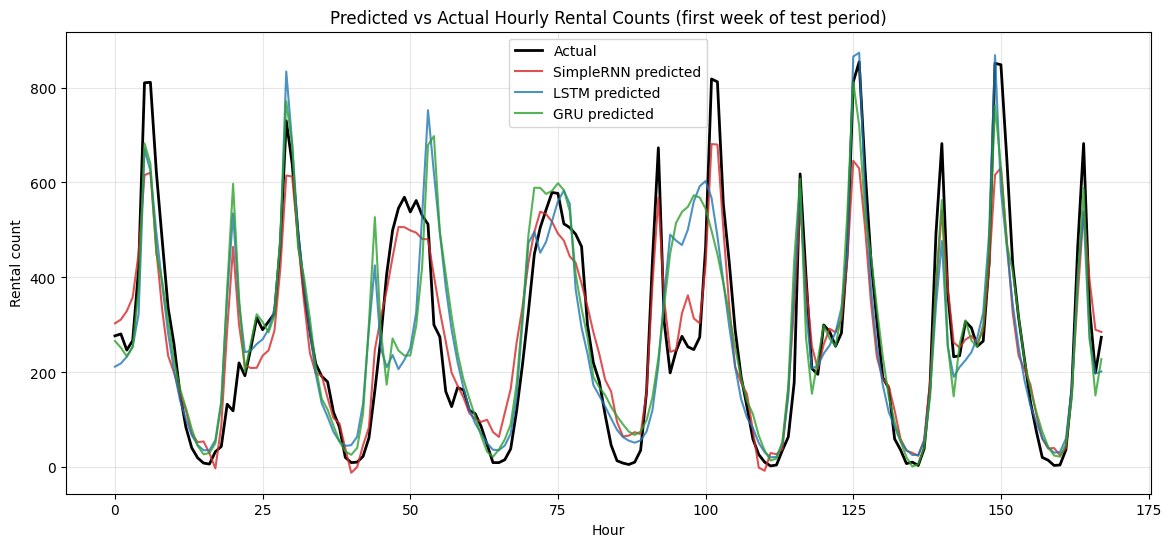

In [18]:
# FIGURE 2: predicted vs actual rental counts (first week of test set = 168 hours)
SPAN = 168
plt.figure(figsize=(14, 6))
plt.plot(final["SimpleRNN"]["true"][:SPAN], color="black", linewidth=2, label="Actual")
for name, color in [("SimpleRNN", "tab:red"), ("LSTM", "tab:blue"), ("GRU", "tab:green")]:
    plt.plot(final[name]["pred"][:SPAN], color=color, alpha=0.8, label=f"{name} predicted")
plt.title("Predicted vs Actual Hourly Rental Counts (first week of test period)")
plt.xlabel("Hour")
plt.ylabel("Rental count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("figure2_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

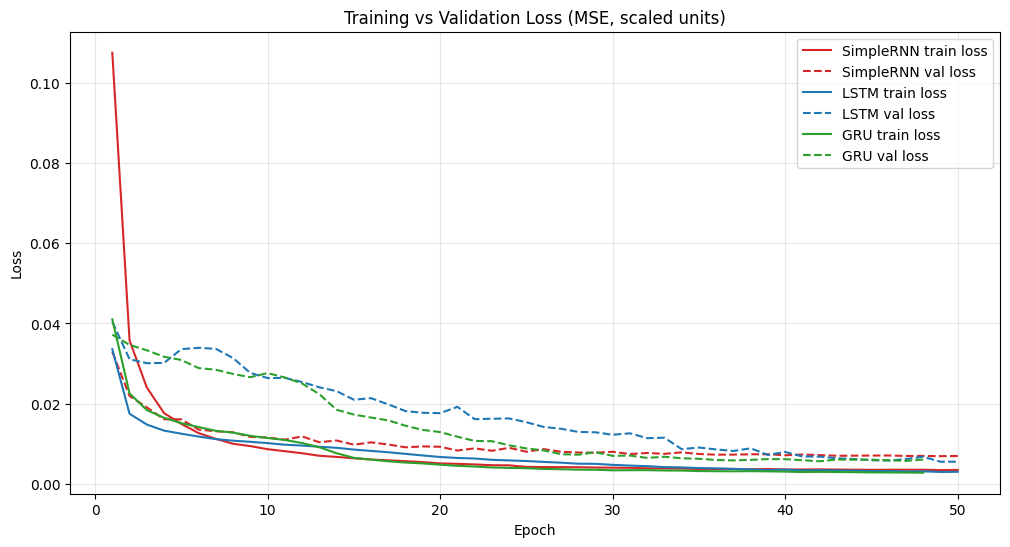

In [19]:
# FIGURE 3: training and validation loss curves for the final configurations
plt.figure(figsize=(12, 6))
for name, color in [("SimpleRNN", "tab:red"), ("LSTM", "tab:blue"), ("GRU", "tab:green")]:
    h = final[name]["history"].history
    epochs_ran = range(1, len(h["loss"]) + 1)
    plt.plot(epochs_ran, h["loss"], color=color, linestyle="-", label=f"{name} train loss")
    plt.plot(epochs_ran, h["val_loss"], color=color, linestyle="--", label=f"{name} val loss")
plt.title("Training vs Validation Loss (MSE, scaled units)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("figure3_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# 6. SUMMARY
print(f"{'Model':<14}{'RMSE':<10}{'MAE':<10}{'Train time (s)':<16}")
for name in ["SimpleRNN", "LSTM", "GRU"]:
    r = final[name]
    print(f"{name:<14}{r['rmse']:<10.2f}{r['mae']:<10.2f}{r['time']:<16.1f}")

best = min(final.values(), key=lambda r: r["rmse"])
print(f"\nLowest RMSE (primary metric): {best['name']} ({best['rmse']:.2f})")

Model         RMSE      MAE       Train time (s)  
SimpleRNN     93.28     65.01     35.5            
LSTM          79.36     54.58     30.7            
GRU           77.80     53.87     28.8            

Lowest RMSE (primary metric): GRU (77.80)
